In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator
# ============================================================
#  Helper: minimum μ for pure rolling at (γ, ω0)
#  Uses rolling-only formulas (no hybrid simulation)
# ============================================================

PHASE_TO_INT = {"R": 0, "S": 1, "D": 2, "H": 3, "Z": 4}
INT_TO_PHASE = {v: k for k, v in PHASE_TO_INT.items()}
def omega2_rolling(theta, gamma, omega0):
    """
    ω(θ)^2 under pure rolling (Theron eq. (11) with θ_r = 0, ω_r = ω0).
    """
    theta = np.asarray(theta)
    num = (1.0 + omega0**2) * (1.0 + gamma)
    denom = 1.0 + gamma * np.cos(theta)
    # Avoid division by zero
    denom = np.where(np.abs(denom) < 1e-10, np.sign(denom) * 1e-10, denom)
    return num / denom - 1.0


def alpha_rolling(theta, gamma, omega2):
    """
    α(θ) under pure rolling (Theron eq. (12)).
    """
    theta = np.asarray(theta)
    omega2 = np.asarray(omega2)
    s = np.sin(theta)
    c = np.cos(theta)
    denom = 1.0 + gamma * c
    denom = np.where(np.abs(denom) < 1e-10, np.sign(denom) * 1e-10, denom)
    return 0.5 * gamma * s * (1.0 + omega2) / denom


def F_over_mg_rolling(theta, gamma, omega2):
    """
    F/(mg) under pure rolling (Theron eq. (13)).
    """
    theta = np.asarray(theta)
    omega2 = np.asarray(omega2)
    s = np.sin(theta)
    return 0.5 * gamma * s * (1.0 - omega2)


def N_over_mg_rolling(theta, gamma, omega2, alpha):
    """
    N/(mg) under pure rolling (Theron eq. (7)).
    """
    theta = np.asarray(theta)
    omega2 = np.asarray(omega2)
    alpha = np.asarray(alpha)
    s = np.sin(theta)
    c = np.cos(theta)
    return 1.0 - gamma * alpha * s - gamma * omega2 * c


def min_mu_for_pure_rolling(gamma, omega0, n_theta=2000):
    """
    μ_min(γ, ω0): smallest μ for which pure rolling is possible over a full revolution:

        μ_min = max_{θ in [0, 2π], N>0} |F/N|(θ)

    using the rolling-only solution.
    """
    theta = np.linspace(0.0, 2.0 * math.pi, n_theta, endpoint=False)
    omega2 = omega2_rolling(theta, gamma, omega0)
    alpha = alpha_rolling(theta, gamma, omega2)
    F_mg = F_over_mg_rolling(theta, gamma, omega2)
    N_mg = N_over_mg_rolling(theta, gamma, omega2, alpha)

    mask = N_mg > 1e-8
    if not np.any(mask):
        return float("inf")

    ratio = np.abs(F_mg[mask] / N_mg[mask])
    return float(np.max(ratio))


# ============================================================
#  Main simulator: rolling + slip (R/S/D) + hop/zero/top
#  Clean output for ML
# ============================================================

def simulate_loaded_hoop(
    gamma=0.75,
    mu=0.4,
    omega0=0.5,
    dtheta=1e-3,
    theta_max=2 * math.pi,
    max_steps=None,   # <-- now optional
):
    """
    Simulate one revolution (or until hop/stop) of a loaded hoop with
    rolling + slipping/spinning, using Theron & Maritz' nondimensional
    equations.

    Parameters
    ----------
    gamma : float
        Eccentricity γ = m_p / (m_h + m_p), in (0, 1].
    mu : float
        Coulomb friction coefficient μ.
    omega0 : float
        Initial non-dimensional angular speed ω0 = sqrt(r/g)*θ̇(0).
        Initial state is rolling, so Vx(0) = ω0.
    dtheta : float
        Step in θ for the integrator.
    theta_max : float
        Upper bound on θ (usually 2π).
    max_steps : int
        Safety cap on total integration steps.

    Returns
    -------
    dict with keys:
        "gamma", "mu", "omega0" : input parameters (for convenience)
        "theta"                 : 1D array of angles θ
        "phase"                 : 1D array of states per θ in {"R","S","D","H","Z"}
        "final_condition"       : "T" (top), "H" (hop), or "Z" (ω → 0)
    """
    # If max_steps not given, choose it so that max_steps * dtheta > theta_max
    if max_steps is None:
        # safety factor 1.1 so we’re comfortably above 2π
        max_steps = int(math.ceil(theta_max / dtheta * 1.1))
    else:
        # Optional: sanity check if user-provided max_steps is likely too small
        if max_steps * dtheta < theta_max:
            print(
                f"Warning: max_steps*dtheta = {max_steps*dtheta:.3g} < theta_max "
                f"({theta_max:.3g}); simulation may stop early."
            )

    # We only keep track of θ and the contact regime per θ.
    thetas = []
    modes = []   # 'R','S','D' while in contact

    # ---------- Initial state: rolling from θ = 0 ----------
    theta = 0.0
    omega = omega0
    Vx = omega0          # rolling ⇒ Vx = ω
    mode = 'R'           # 'R','S','D'
    theta_r = theta      # start of current rolling phase
    omega_r = omega

    final_condition = None

    # ---------- Rolling formulas (Sec. 2.3) ----------

    def rolling_omega(theta_val, theta_r_val, omega_r_val, gamma_val):
        # Eq (11): energy integral in rolling
        num = (1 + omega_r_val**2) * (1 + gamma_val * math.cos(theta_r_val))
        den = (1 + gamma_val * math.cos(theta_val))
        return math.sqrt(max(num / den - 1.0, 0.0))

    def rolling_forces(theta_val, omega_val, gamma_val):
        # Eqs (12), (7), (13)
        c = math.cos(theta_val)
        s = math.sin(theta_val)

        alpha_val = 0.5 * gamma_val * s * (1 + omega_val**2) / (1 + gamma_val * c)
        N_val = 1.0 - gamma_val * alpha_val * s - gamma_val * omega_val**2 * c
        F_val = 0.5 * gamma_val * s * (1 - omega_val**2)
        return N_val, F_val, alpha_val

    # ---------- Slipping/spinning derivatives (Sec. 2.4) ----------

    def slip_derivs(theta_val, y_val, Vx_val, gamma_val, mu_val, slip_type):
        """
        Derivatives dy/dθ and dVx/dθ during slipping / spinning.
        y = ω². Based on Eqs. (15)-(16) + Newton in x (Eq. 6).
        """
        s = math.sin(theta_val)
        c = math.cos(theta_val)

        # S = γ sinθ ± μ(1+γcosθ)
        if slip_type == 'S':   # spinning, F = +μN, rθ̇ > Ẋ
            S = gamma_val * s - mu_val * (1 + gamma_val * c)
        else:                  # skidding, F = -μN, rθ̇ < Ẋ
            S = gamma_val * s + mu_val * (1 + gamma_val * c)

        # Denominator in Eq (15)
        denom = (1 - gamma_val**2 + S * gamma_val * s)
        if abs(denom) < 1e-12:
            denom = 1e-12 if denom >= 0 else -1e-12

        # Eq (16): d(ω²)/dθ
        dy_dtheta = 2 * S * (1 - gamma_val * c * y_val) / denom

        # Eq (15): α
        alpha_val = S * (1 - gamma_val * c * y_val) / denom

        # ω
        omega_val = math.sqrt(max(y_val, 0.0))

        # Normal reaction N (Eq. 7)
        N_val = 1.0 - gamma_val * alpha_val * s - gamma_val * y_val * c

        # Coulomb friction
        F_val = mu_val * N_val if slip_type == 'S' else -mu_val * N_val

        # Tangential acceleration, Eq. (6):
        # F = X¨/g + γ α cosθ - γ ω² sinθ  ⇒ X¨/g = F - γαcosθ + γω²sinθ
        Ax_val = F_val - gamma_val * alpha_val * c + gamma_val * y_val * s

        # dVx/dθ = (X¨/g) / ω
        if omega_val < 1e-10:
            dV_dtheta = 0.0
        else:
            dV_dtheta = Ax_val / omega_val

        return dy_dtheta, dV_dtheta, N_val, F_val, alpha_val

    steps = 0
    last_slip_theta = None

    # ---------- Main integration loop ----------
    while steps < max_steps:
        steps += 1

        # Store current state (for ML: just θ and mode)
        thetas.append(theta)
        modes.append(mode)

        # Forces at current point for stop conditions
        if mode == 'R':
            N, F, alpha = rolling_forces(theta, omega, gamma)
        else:
            _, _, N, F, alpha = slip_derivs(theta, omega**2, Vx, gamma, mu, mode)

        # Final conditions at current point
        if N <= 0:
            final_condition = 'H'
            break
        if omega <= 0:
            final_condition = 'Z'
            break
        if theta >= theta_max:
            final_condition = 'T'
            break

        # ---------- Advance one θ-step ----------
        if mode == 'R':
            # Rolling: analytic ω(θ)
            theta_next = min(theta + dtheta, theta_max)
            omega_next = rolling_omega(theta_next, theta_r, omega_r, gamma)
            N_next, F_next, alpha_next = rolling_forces(theta_next, omega_next, gamma)
            Vx_next = omega_next

            # Onset of slipping: |F| > μN with small margin
            if abs(F_next) > (mu * N_next) * (1 + 1e-3):
                # avoid chattering: require a few dθ between slip events
                if last_slip_theta is None or theta_next - last_slip_theta > 5 * dtheta:
                    theta = theta_next
                    omega = omega_next
                    Vx = Vx_next
                    mode = 'S' if F_next > 0 else 'D'
                    last_slip_theta = theta
                else:
                    theta, omega, Vx = theta_next, omega_next, Vx_next
            else:
                theta, omega, Vx = theta_next, omega_next, Vx_next

        else:
            # Slipping/spinning: integrate ω² and Vx with RK4 in θ
            slip_type = mode
            y = omega**2
            h = dtheta

            k1_y, k1_V, *_ = slip_derivs(theta, y, Vx, gamma, mu, slip_type)
            k2_y, k2_V, *_ = slip_derivs(theta + 0.5 * h, y + 0.5 * h * k1_y,
                                         Vx + 0.5 * h * k1_V, gamma, mu, slip_type)
            k3_y, k3_V, *_ = slip_derivs(theta + 0.5 * h, y + 0.5 * h * k2_y,
                                         Vx + 0.5 * h * k2_V, gamma, mu, slip_type)
            k4_y, k4_V, *_ = slip_derivs(theta + h, y + h * k3_y,
                                         Vx + h * k3_V, gamma, mu, slip_type)

            y_next = max(y + (h / 6.0) * (k1_y + 2 * k2_y + 2 * k3_y + k4_y), 0.0)
            omega_next = math.sqrt(y_next)
            Vx_next = Vx + (h / 6.0) * (k1_V + 2 * k2_V + 2 * k3_V + k4_V)
            theta_next = theta + h

            _, _, N_next, F_next, alpha_next = slip_derivs(theta_next, y_next, Vx_next,
                                                           gamma, mu, slip_type)

            # Final conditions at new point
            if N_next <= 0:
                theta, omega, Vx = theta_next, omega_next, Vx_next
                thetas.append(theta)
                modes.append(mode)
                final_condition = 'H'
                break
            if omega_next <= 0:
                theta, omega, Vx = theta_next, omega_next, Vx_next
                thetas.append(theta)
                modes.append(mode)
                final_condition = 'Z'
                break
            if theta_next >= theta_max:
                theta, omega, Vx = theta_next, omega_next, Vx_next
                thetas.append(theta)
                modes.append(mode)
                final_condition = 'T'
                break

            # Condition to go back to rolling: relative slip velocity → 0
            go_roll = False
            if slip_type == 'S' and omega_next <= Vx_next:
                go_roll = True
            if slip_type == 'D' and omega_next >= Vx_next:
                go_roll = True

            if go_roll:
                theta, omega, Vx = theta_next, omega_next, omega_next
                mode = 'R'
                theta_r, omega_r = theta, omega
            else:
                theta, omega, Vx = theta_next, omega_next, Vx_next

    # ---------- Pack result for ML ----------

    thetas = np.array(thetas)
    phases = np.array(modes, dtype='<U1')

    # Encode terminal event as the last label
    if final_condition == 'H':
        phases[-1] = 'H'
    elif final_condition == 'Z':
        phases[-1] = 'Z'
    # If 'T', we leave the final contact phase as R/S/D.

    return {
        "gamma": gamma,
        "mu": mu,
        "omega0": omega0,
        "theta": thetas,
        "phase": phases,
        "final_condition": final_condition,
    }

# Color map for phases
PHASE_COLORS = {
    "R": "gray",
    "S": "blue",
    "D": "red",
    "H": "white",
    "Z": "black",
}


def plot_phase_trajectory(sim_result, title=None):
    """
    Plot phase (R,S,D,H,Z) vs θ (in degrees) for a single simulation result.
    """
    theta_rad = sim_result["theta"]
    phase = sim_result["phase"]

    # Convert to degrees for plotting
    theta_deg = theta_rad * 180.0 / math.pi

    plt.figure(figsize=(8, 2.5))

    y = np.zeros_like(theta_deg)
    for p in ["R", "S", "D", "H", "Z"]:
        mask = (phase == p)
        if np.any(mask):
            plt.scatter(theta_deg[mask], y[mask],
                        s=10,
                        label=p,
                        color=PHASE_COLORS.get(p, "black"))

    plt.yticks([])
    plt.xlabel(r"$\theta$ (deg)")
    plt.xlim(theta_deg.min(), theta_deg.max())

    if title is None:
        title = fr"Phase trajectory, $\gamma={sim_result['gamma']:.2f}$, " \
                fr"$\mu={sim_result['mu']:.2f}$, $\omega_0={sim_result['omega0']:.2f}$"
    plt.title(title)

    plt.legend(loc="upper right", ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()

def phase_diagram_theta_omega0(
    gamma=0.75,
    mu=0.4,
    n_omega0=200,          # many samples for smoothness
    theta_max=2 * math.pi,
    dtheta_sim=1e-3,
):
    """
    Phase diagram in (θ, ω0) for fixed (gamma, mu).

    - ω0 automatically ranges from ~0 up to 1/sqrt(gamma).
    - θ shown in degrees on the x-axis (internally still in radians).
    - θ resolution follows the simulator's dtheta (no downsampling).
    """
    # ---- ω0 range: (0, 1/sqrt(γ)) ----
    omega0_max = 1.0 / math.sqrt(gamma)
    omega0_min = 0.02 * omega0_max
    omega0_hi  = 0.98 * omega0_max
    omega0_values = np.linspace(omega0_min, omega0_hi, n_omega0)

    # ---- θ grid in radians, then convert to degrees for plotting ----
    theta_grid_rad = np.arange(0.0, theta_max + 0.5 * dtheta_sim, dtheta_sim)
    n_theta = len(theta_grid_rad)
    theta_grid_deg = theta_grid_rad * 180.0 / math.pi
    theta_max_deg = theta_max * 180.0 / math.pi

    # Phase ↔ int mapping
    phase_to_int = {"R": 0, "S": 1, "D": 2, "H": 3, "Z": 4}
    int_to_phase = {v: k for k, v in phase_to_int.items()}

    phase_img = np.zeros((n_omega0, n_theta), dtype=int)

    for i, omega0 in enumerate(omega0_values):
        sim = simulate_loaded_hoop(
            gamma=gamma,
            mu=mu,
            omega0=omega0,
            dtheta=dtheta_sim,
            theta_max=theta_max,
        )

        theta_sim = sim["theta"]
        phase_sim = sim["phase"]
        final_cond = sim["final_condition"]

        # For each θ in the grid, take the latest simulated state at θ' ≤ θ
        idx = np.searchsorted(theta_sim, theta_grid_rad, side="right") - 1
        idx = np.clip(idx, 0, len(theta_sim) - 1)
        phase_at_grid = phase_sim[idx].astype("<U1")

        # Fill beyond the last θ with final condition if H/Z
        if final_cond in ("H", "Z"):
            beyond = theta_grid_rad > theta_sim[-1]
            phase_at_grid[beyond] = final_cond

        row = np.array([phase_to_int.get(p, 0) for p in phase_at_grid], dtype=int)
        phase_img[i, :] = row

    # ---- Plot ----
    plt.figure(figsize=(9, 4))

    colors = [
        PHASE_COLORS["R"],
        PHASE_COLORS["S"],
        PHASE_COLORS["D"],
        PHASE_COLORS["H"],
        PHASE_COLORS["Z"],
    ]
    cmap = ListedColormap(colors)

    extent = [0.0, theta_max_deg, omega0_min, omega0_hi]

    plt.imshow(
        phase_img,
        aspect="auto",
        origin="lower",
        extent=extent,
        cmap=cmap,
        interpolation="nearest",
    )

    cbar = plt.colorbar(ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(int_to_phase)
    cbar.set_label("Phase")

    plt.xlabel(r"$\theta$ (deg)")
    plt.ylabel(r"$\omega_0$")
    plt.title(fr"Phase diagram in $(\theta, \omega_0)$ for $\gamma={gamma:.2f}, \ \mu={mu:.2f}$")

    # ---- Ticks & grid like Theron: 30° in θ, 0.1 in ω0 ----
    ax = plt.gca()

    ax.set_xlim(0, theta_max_deg)
    y_min = 0.0
    y_max = math.ceil(omega0_hi * 10) / 10.0
    ax.set_ylim(y_min, y_max)

    ax.xaxis.set_major_locator(MultipleLocator(30))   # 30° steps
    ax.yaxis.set_major_locator(MultipleLocator(0.1))  # 0.1 steps

    ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()

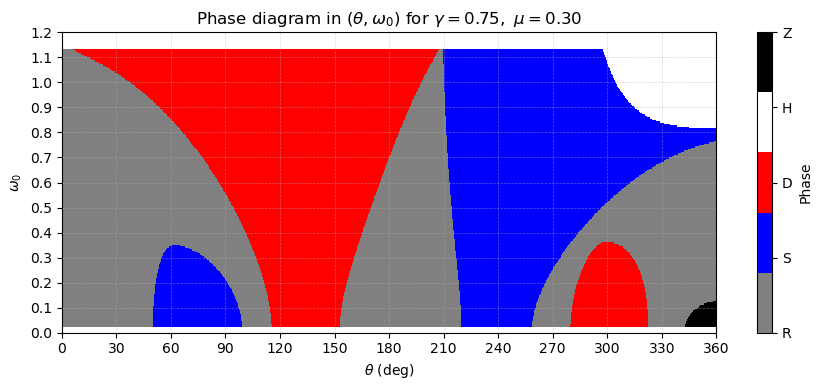

In [ ]:
phase_diagram_theta_omega0(
    gamma=0.75,
    mu=0.3,
    n_omega0=200,
    theta_max=2 * math.pi,
    dtheta_sim=1e-3,
)


In [ ]:
def test_max_steps_behavior():
    gamma = 0.75
    mu = 0.4
    omega0 = 0.5
    theta_max = 2 * math.pi

    dtheta_values = [1e-3, 5e-4, 1e-4, 1e-5]

    print("=== Auto max_steps (None) ===")
    for dtheta in dtheta_values:
        res = simulate_loaded_hoop(
            gamma=gamma,
            mu=mu,
            omega0=omega0,
            dtheta=dtheta,
            theta_max=theta_max,
            max_steps=None,   # auto
        )
        theta_end = res["theta"][-1]
        print(
            f"dtheta = {dtheta:7.1e} -> theta_end = {theta_end:.4f} rad "
            f"({theta_end*180/math.pi:.1f} deg), final = {res['final_condition']}"
        )

    print("\n=== Manual too-small max_steps ===")
    # Pick a ridiculous max_steps that is too small for small dtheta
    manual_max_steps = 200_000
    for dtheta in dtheta_values:
        print(f"\nTrying dtheta = {dtheta:7.1e} with max_steps = {manual_max_steps}")
        res = simulate_loaded_hoop(
            gamma=gamma,
            mu=mu,
            omega0=omega0,
            dtheta=dtheta,
            theta_max=theta_max,
            max_steps=manual_max_steps,   # manual override
        )
        theta_end = res["theta"][-1]
        print(
            f" -> theta_end = {theta_end:.4f} rad "
            f"({theta_end*180/math.pi:.1f} deg), final = {res['final_condition']}"
        )

# Run the test
test_max_steps_behavior()


=== Auto max_steps (None) ===
dtheta = 1.0e-03 -> theta_end = 6.2832 rad (360.0 deg), final = T
dtheta = 5.0e-04 -> theta_end = 6.2832 rad (360.0 deg), final = T
dtheta = 1.0e-04 -> theta_end = 6.2832 rad (360.0 deg), final = T
dtheta = 1.0e-05 -> theta_end = 6.2832 rad (360.0 deg), final = T

=== Manual too-small max_steps ===

Trying dtheta = 1.0e-03 with max_steps = 200000
 -> theta_end = 6.2832 rad (360.0 deg), final = T

Trying dtheta = 5.0e-04 with max_steps = 200000
 -> theta_end = 6.2832 rad (360.0 deg), final = T

Trying dtheta = 1.0e-04 with max_steps = 200000
 -> theta_end = 6.2832 rad (360.0 deg), final = T

Trying dtheta = 1.0e-05 with max_steps = 200000
 -> theta_end = 2.0000 rad (114.6 deg), final = None


Final condition: T
Number of samples: 628320


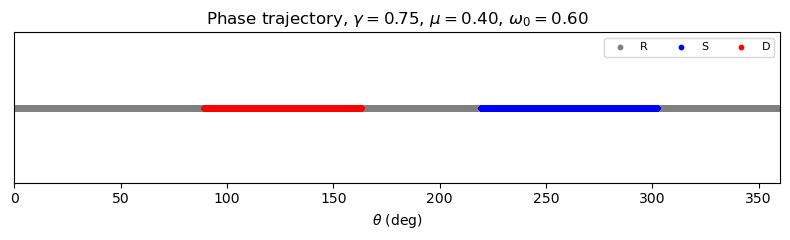

In [ ]:
# Example 1: simple trajectory and phase plot
res = simulate_loaded_hoop(
    gamma=0.75,
    mu=0.4,
    omega0=0.6,
    dtheta=1e-5,        # fine enough
    theta_max=2*math.pi # full revolution
)

print("Final condition:", res["final_condition"])
print("Number of samples:", len(res["theta"]))

plot_phase_trajectory(res)


In [ ]:
# Test μ_min(γ, ω0) for specific values from Theron's figure

gamma = 2/3
omega0_values = [0.0, 0.317, 0.7, 1.0]

print(f"Testing μ_min for gamma = {gamma:.6f}")
print("------------------------------------")

for w0 in omega0_values:
    mu_min = min_mu_for_pure_rolling(gamma, w0, n_theta=5000)
    print(f"ω0 = {w0:0.3f}  -->  μ_min ≈ {mu_min:.6f}")


Testing μ_min for gamma = 0.666667
------------------------------------
ω0 = 0.000  -->  μ_min ≈ 0.289600
ω0 = 0.317  -->  μ_min ≈ 0.256746
ω0 = 0.700  -->  μ_min ≈ 0.554222
ω0 = 1.000  -->  μ_min ≈ 1.749437


## Dataset Construction: 19×19×19 Parameter Grid

We now generate the full supervised dataset for phase prediction.  
The parameter space is discretized as a structured 3D grid:

- **Eccentricity** \(\gamma \in (0,1)\):  
  19 values between 0.05 and 0.95.
- **Initial angular speed** \(\omega_0 \in (0, 1/\sqrt{\gamma})\):  
  for each \(\gamma\), 19 values corresponding to 5%–95% of the upper bound \(1/\sqrt{\gamma}\).
- **Friction coefficient** \(\mu \in (0, \mu_{\min}(\gamma,\omega_0))\):  
  for each pair \((\gamma,\omega_0)\), we compute \(\mu_{\min}\) from the rolling-only solution and take 19 values between 5% and 95% of \(\mu_{\min}\).

This yields a grid of
\[
19 \times 19 \times 19 = 6859
\]
parameter triples \((\gamma,\mu,\omega_0)\), all lying strictly in the **hybrid regime**
(where pure rolling is impossible for a full revolution).

For each triple, we:

1. Run a detailed simulation using the hybrid dynamics model (rolling + spinning + skidding + hop/stop).
2. Sample **100 evenly spaced angles** \(\theta \in [0,2\pi)\).
3. Record the phase label \(\text{R}, \text{S}, \text{D}, \text{H}, \text{Z}\) at each sampled \(\theta\).

Each dataset row has the form
\[
X = (\gamma, \mu, \omega_0, \theta), \qquad
y \in \{0,1,2,3,4\},
\]
where the integer label encodes one of the five regimes (R, S, D, H, Z).  
The code below generates the full set of parameter triples and builds the corresponding \((X,y)\) arrays.


In [13]:
PHASE_TO_INT = {"R": 0, "S": 1, "D": 2, "H": 3, "Z": 4}
INT_TO_PHASE = {v: k for k, v in PHASE_TO_INT.items()}
# ============================================================
# Helper: 19 clean fractions from 5% to 95%
# {0.05, 0.10, ..., 0.95}
# ============================================================
def frac_grid_19():
    """
    Return 19 fractions between 0.05 and 0.95 inclusive,
    in clean 5% steps:
        [0.05, 0.10, ..., 0.95]
    """
    return np.linspace(0.05, 0.95, 19)


# ============================================================
# Parameter generation: 19×19×19 grid
# ============================================================
def generate_param_triples_19(
    n_theta_mu_min=2000,
    gamma_min_frac=0.05,
    gamma_max_frac=0.95,
):
    """
    Generate a list of (gamma, mu, omega0) triples using 19 values for each:

      - gamma:  19 values in (0, 1), here from 0.05 to 0.95
      - omega0: 19 values in (0, 1/sqrt(gamma)), scaled by the same 5–95% fractions
      - mu:     19 values in (0, mu_min(gamma, omega0)),
                also scaled by 5–95% fractions

    The fractions are:
        {0.05, 0.10, ..., 0.95}

    Returns
    -------
    params : list of (gamma, mu, omega0)
    """
    frac19 = frac_grid_19()

    # Gamma values in (0,1), restricted to [0.05, 0.95] for sanity
    gammas = np.linspace(gamma_min_frac, gamma_max_frac, 19)

    params = []

    for gamma in gammas:
        # Max omega0 for this gamma
        omega0_max = 1.0 / math.sqrt(gamma)

        # 19 omega0 values: 0.05, 0.10, ..., 0.95 of omega0_max
        omega0_vals = frac19 * omega0_max

        for omega0 in omega0_vals:
            # Compute mu_min for (gamma, omega0) from pure rolling
            mu_min = min_mu_for_pure_rolling(gamma, omega0, n_theta=n_theta_mu_min)

            # Skip degenerate cases
            if not np.isfinite(mu_min) or mu_min <= 0.0:
                continue

            # 19 mu values: 0.05..0.95 of mu_min
            mu_vals = frac19 * mu_min

            for mu in mu_vals:
                params.append((gamma, mu, omega0))

    return params


# ============================================================
# Simulate one triple and sample 100 θ-values
# ============================================================
def simulate_and_sample_one(
    gamma,
    mu,
    omega0,
    theta_max=2 * math.pi,
    dtheta_sim=1e-3,
    n_theta_samples=100,
):
    """
    Run one simulation for (gamma, mu, omega0), then sample n_theta_samples
    evenly spaced theta's in [0, theta_max), assigning a phase to each.

    Returns
    -------
    theta_sample : (n_theta_samples,) array of theta values
    phase_sample : (n_theta_samples,) array of phase chars {'R','S','D','H','Z'}
    final_condition : 'T','H','Z', or None
    """
    sim = simulate_loaded_hoop(
        gamma=gamma,
        mu=mu,
        omega0=omega0,
        dtheta=dtheta_sim,
        theta_max=theta_max,
    )

    theta_sim = sim["theta"]
    phase_sim = sim["phase"]
    final_cond = sim["final_condition"]

    # Target theta grid (0 .. theta_max)
    theta_sample = np.linspace(0.0, theta_max, n_theta_samples, endpoint=False)

    # For each θ_sample, take the latest simulated state at θ' ≤ θ_sample
    idx = np.searchsorted(theta_sim, theta_sample, side="right") - 1
    idx = np.clip(idx, 0, len(theta_sim) - 1)
    phase_at_grid = phase_sim[idx].astype("<U1")

    # If hop or zero happened early, fill beyond last θ with that final state
    if final_cond in ("H", "Z"):
        beyond = theta_sample > theta_sim[-1]
        phase_at_grid[beyond] = final_cond

    return theta_sample, phase_at_grid, final_cond


# ============================================================
# Build the full (X, y) dataset from the 19×19×19 grid
# ============================================================
def build_phase_dataset_from_triples(
    params,
    theta_max=2 * math.pi,
    dtheta_sim=1e-3,
    n_theta_samples=100,
):
    """
    Build a supervised dataset for phase classification from
    a list of (gamma, mu, omega0) parameter triples.

    Each row:
        X = [gamma, mu, omega0, theta]
        y = int label in {0,1,2,3,4} for R,S,D,H,Z.

    Returns
    -------
    X : (N, 4) ndarray
    y : (N,) ndarray
    """
    X_list = []
    y_list = []

    for (gamma, mu, omega0) in params:
        theta_sample, phase_sample, final_cond = simulate_and_sample_one(
            gamma=gamma,
            mu=mu,
            omega0=omega0,
            theta_max=theta_max,
            dtheta_sim=dtheta_sim,
            n_theta_samples=n_theta_samples,
        )

        for theta_val, phase_char in zip(theta_sample, phase_sample):
            if phase_char not in PHASE_TO_INT:
                continue  # safety
            X_list.append([gamma, mu, omega0, theta_val])
            y_list.append(PHASE_TO_INT[phase_char])

    X = np.array(X_list, dtype=float)
    y = np.array(y_list, dtype=int)
    return X, y


# ============================================================
# Example: generate params and dataset
# ============================================================
# Generate ~19*19*19 ≈ 6859 param triples
params_19 = generate_param_triples_19(n_theta_mu_min=2000)
print("Number of (γ, μ, ω0) triples:", len(params_19))

# Build dataset (this might take a bit, but should be fine)
X, y = build_phase_dataset_from_triples(
    params_19,
    theta_max=2 * math.pi,
    dtheta_sim=1e-3,
    n_theta_samples=100,
)

print("X shape:", X.shape)  # ~ (6859 * 100, 4)
print("y shape:", y.shape)
print("Label counts:", {INT_TO_PHASE[i]: np.sum(y == i) for i in np.unique(y)})

# Optionally save
# np.savez("hopping_hoop_phase_dataset_19grid.npz", X=X, y=y)


Number of (γ, μ, ω0) triples: 6859
X shape: (685900, 4)
y shape: (685900,)
Label counts: {'R': np.int64(264710), 'S': np.int64(222779), 'D': np.int64(180533), 'H': np.int64(6779), 'Z': np.int64(11099)}


### Dataset Summary and Class Balance

The grid construction above produces:

- **Number of parameter triples**: 6859  
- **Feature matrix**: \(X \in \mathbb{R}^{685900 \times 4}\)  
- **Labels**: \(y \in \{0,1,2,3,4\}^{685900}\)

The phase-label counts are:

- R (rolling): 264,710 samples  
- S (spinning): 222,779 samples  
- D (skidding): 180,533 samples  
- H (hop): 6,779 samples  
- Z (zero velocity / stop): 11,099 samples  

As expected, the majority of points lie in the contact regimes (R, S, D), while terminal events (H, Z) are relatively rare. This mild class imbalance is physically meaningful (hops and full stops occur only in specific corners of parameter space) and can be handled later using standard techniques such as:

- class-weighted loss functions, or  
- oversampling of H/Z examples in training.

Overall, the dataset densely covers the nontrivial hybrid behavior of the loaded hoop and is large enough (\(\approx 6.9\times 10^5\) labeled points) to support training small neural networks for phase prediction and state-map reconstruction.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# ----------------------------------------------------------
# 0. Basic dataset info
# ----------------------------------------------------------
N, D = X.shape
print("Total samples =", N, "Feature dim =", D)

theta_count = 100  # because each simulation produced 100 θ samples
num_sims = N // theta_count
assert N % theta_count == 0, "Dataset size is not divisible by theta_count"

print("Number of simulations =", num_sims)

# ----------------------------------------------------------
# 1. Construct simulation IDs
# ----------------------------------------------------------
# sim_id = 0 for first 100 rows, 1 for next 100, ..., up to 6858
sim_ids = np.repeat(np.arange(num_sims), theta_count)

# ----------------------------------------------------------
# 2. Split by SIMULATION, not by row
# ----------------------------------------------------------
train_sims, temp_sims = train_test_split(
    np.arange(num_sims),
    test_size=0.30,
    random_state=0,
    shuffle=True
)

val_sims, test_sims = train_test_split(
    temp_sims,
    test_size=0.50,
    random_state=0,
    shuffle=True
)

print("Train sims:", len(train_sims))
print("Val sims:",   len(val_sims))
print("Test sims:",  len(test_sims))

# Masks for row selection
train_mask = np.isin(sim_ids, train_sims)
val_mask   = np.isin(sim_ids, val_sims)
test_mask  = np.isin(sim_ids, test_sims)

# ----------------------------------------------------------
# 3. Apply masks
# ----------------------------------------------------------
X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Train size:", X_train.shape[0])
print("Val size:",   X_val.shape[0])
print("Test size:",  X_test.shape[0])

# ----------------------------------------------------------
# 4. Standardization (fit on train only)
# ----------------------------------------------------------
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std   = scaler.transform(X_val)
X_test_std  = scaler.transform(X_test)

# ----------------------------------------------------------
# 5. Define an MLP (same architecture as before)
# ----------------------------------------------------------
clf = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    batch_size=1024,
    learning_rate_init=1e-3,
    max_iter=200,
    verbose=True,
    random_state=0,
)

# ----------------------------------------------------------
# 6. Train
# ----------------------------------------------------------
clf.fit(X_train_std, y_train)

# ----------------------------------------------------------
# 7. Evaluate
# ----------------------------------------------------------
y_val_pred  = clf.predict(X_val_std)
y_test_pred = clf.predict(X_test_std)

print("\nValidation accuracy:", accuracy_score(y_val, y_val_pred))
print("Test accuracy:",        accuracy_score(y_test, y_test_pred))

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred))

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, y_test_pred))


Total samples = 685900 Feature dim = 4
Number of simulations = 6859
Train sims: 4801
Val sims: 1029
Test sims: 1029
Train size: 480100
Val size: 102900
Test size: 102900
Iteration 1, loss = 0.79137073
Iteration 2, loss = 0.56420695
Iteration 3, loss = 0.53386805
Iteration 4, loss = 0.51833244
Iteration 5, loss = 0.50786778
Iteration 6, loss = 0.50011522
Iteration 7, loss = 0.49504184
Iteration 8, loss = 0.49027638
Iteration 9, loss = 0.48681779
Iteration 10, loss = 0.48412758
Iteration 11, loss = 0.48118497
Iteration 12, loss = 0.47913430
Iteration 13, loss = 0.47763306
Iteration 14, loss = 0.47626761
Iteration 15, loss = 0.47454060
Iteration 16, loss = 0.47385632
Iteration 17, loss = 0.47232346
Iteration 18, loss = 0.47198269
Iteration 19, loss = 0.47085963
Iteration 20, loss = 0.46972135
Iteration 21, loss = 0.46896476
Iteration 22, loss = 0.46826305
Iteration 23, loss = 0.46798628
Iteration 24, loss = 0.46686154
Iteration 25, loss = 0.46651937
Iteration 26, loss = 0.46596578
Iterati

c:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Validation accuracy: 0.8051797862001944
Test accuracy: 0.8115160349854227

Classification report (test):
              precision    recall  f1-score   support

           0       0.84      0.72      0.78     37902
           1       0.80      0.85      0.83     34331
           2       0.80      0.88      0.84     27811
           3       0.90      0.89      0.89      1039
           4       0.71      0.82      0.76      1817

    accuracy                           0.81    102900
   macro avg       0.81      0.83      0.82    102900
weighted avg       0.81      0.81      0.81    102900


Confusion matrix (test):
[[27331  5774  4463    10   324]
 [ 3423 29293  1488    95    32]
 [ 1596  1497 24464     0   254]
 [   16   102     0   921     0]
 [  122     0   199     0  1496]]


In [ ]:
import numpy as np

print("X shape:", X.shape)
print("y shape:", y.shape)

# Save raw dataset with 4 features: [gamma, mu, omega0, theta]
np.savez("dataset.npz", X=X, y=y)
print("Saved to dataset.npz")


X shape: (685900, 4)
y shape: (685900,)
Saved to hoop_dataset_19grid_theta_raw.npz


In [ ]:
from google.colab import files
uploaded = files.upload()  # choose your hoop_dataset_...npz file

Saving hoop_dataset_19grid_theta_raw.npz to hoop_dataset_19grid_theta_raw.npz


In [6]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


Torch version: 2.9.0+cu126
CUDA available: True


device(type='cuda')

In [2]:
# Change the filename here if you used a different name
data = np.load("dataset.npz")

X = data["X"]  # (N, 4): [gamma, mu, omega0, theta]
y = data["y"]  # (N,)
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (685900, 4)
y shape: (685900,)


In [7]:
N, D = X.shape
theta_count = 100
assert N % theta_count == 0, "N not divisible by 100, check theta_count"

num_sims = N // theta_count
print("num_sims =", num_sims)

# sim_id 0 for rows 0..99, 1 for 100..199, etc.
sim_ids = np.repeat(np.arange(num_sims), theta_count)

sim_indices = np.arange(num_sims)

# 70 / 15 / 15 split on simulations
train_sims, temp_sims = train_test_split(
    sim_indices, test_size=0.30, random_state=0, shuffle=True
)
val_sims, test_sims = train_test_split(
    temp_sims, test_size=0.50, random_state=0, shuffle=True
)

print("Train sims:", len(train_sims))
print("Val sims:  ", len(val_sims))
print("Test sims: ", len(test_sims))

train_mask = np.isin(sim_ids, train_sims)
val_mask   = np.isin(sim_ids, val_sims)
test_mask  = np.isin(sim_ids, test_sims)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Train size:", X_train.shape[0])
print("Val size:",   X_val.shape[0])
print("Test size:",  X_test.shape[0])


num_sims = 6859
Train sims: 4801
Val sims:   1029
Test sims:  1029
Train size: 480100
Val size: 102900
Test size: 102900


In [8]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std   = scaler.transform(X_val)
X_test_std  = scaler.transform(X_test)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Instantiate Multinomial Logistic Regression model
# solver='lbfgs' is a good choice for multinomial loss, and 'max_iter' might need adjustment
# C is the inverse of regularization strength; smaller values specify stronger regularization.
log_reg_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500, # Increased max_iter for potential convergence with more complex data
    random_state=0,
    verbose=1 # To see convergence info
)

print("Training Multinomial Logistic Regression model...")
# Fit the model on the standardized training data
log_reg_model.fit(X_train_std, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_std)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"\nTest Accuracy (Multinomial Logistic Regression): {accuracy_log_reg:.4f}")

# Define target names for better readability in reports
target_names = [INT_TO_PHASE[i] for i in sorted(np.unique(y_test))]

print("\nClassification Report (Multinomial Logistic Regression):")
print(classification_report(y_test, y_pred_log_reg, target_names=target_names))

print("\nConfusion Matrix (Multinomial Logistic Regression):")
print(confusion_matrix(y_test, y_pred_log_reg))


Training Multinomial Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete.

Test Accuracy (Multinomial Logistic Regression): 0.5162

Classification Report (Multinomial Logistic Regression):
              precision    recall  f1-score   support

           R       0.49      0.63      0.55     37902
           S       0.53      0.55      0.54     34331
           D       0.55      0.31      0.40     27811
           H       0.54      0.46      0.50      1039
           Z       0.62      0.63      0.63      1817

    accuracy                           0.52    102900
   macro avg       0.55      0.52      0.52    102900
weighted avg       0.52      0.52      0.51    102900


Confusion Matrix (Multinomial Logistic Regression):
[[23836  8517  4663   329   557]
 [12736 19037  2460    86    12]
 [11744  7317  8619     0   131]
 [  297   260     2   480     0]
 [    0   667     0     0  1150]]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   20.5s finished


In [ ]:
class PhaseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = PhaseDataset(X_train_std, y_train)
val_ds   = PhaseDataset(X_val_std,   y_val)
test_ds  = PhaseDataset(X_test_std,  y_test)

train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=4096, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=4096, shuffle=False)


In [ ]:
class PhaseMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=256, num_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x):
        return self.net(x)  # logits

num_classes = 5
model = PhaseMLP(input_dim=4, hidden_dim=256, num_classes=num_classes).to(device)
model


PhaseMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=5, bias=True)
  )
)

In [ ]:
# Compute class weights from training labels
counts = np.bincount(y_train, minlength=num_classes)
class_weights = counts.sum() / (counts + 1e-8)
class_weights = class_weights / class_weights.mean()
print("Class weights:", class_weights)

class_weights_t = torch.from_numpy(class_weights).float().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Class weights: [0.07343899 0.08823334 0.10857024 2.92254581 1.80721162]


In [ ]:
def eval_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            logits = model(Xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.numel()
    return correct / total

num_epochs = 1

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * Xb.size(0)
        total_samples += Xb.size(0)

    train_loss = running_loss / total_samples
    val_acc = eval_accuracy(val_loader)
    print(f"Epoch {epoch:02d} | train loss = {train_loss:.4f} | val acc = {val_acc:.4f}")

test_acc = eval_accuracy(test_loader)
print("Final test accuracy:", test_acc)


Epoch 01 | train loss = 0.1718 | val acc = 0.8871
Final test accuracy: 0.8951409135082604


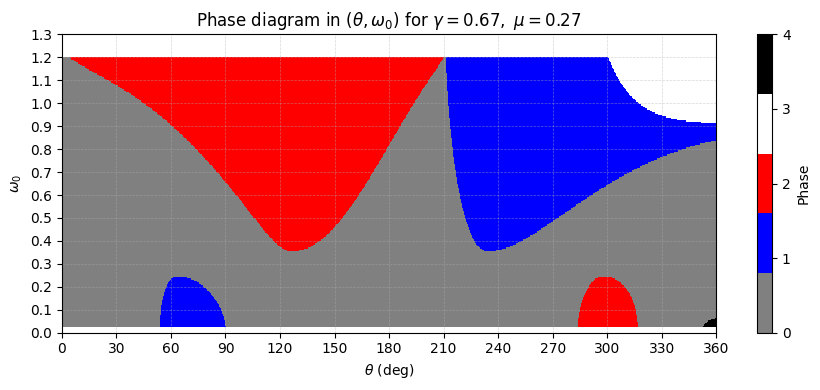

In [ ]:
phase_diagram_theta_omega0(
    gamma=2/3,
    mu=0.27,
    n_omega0=200,
    theta_max=2 * math.pi,
    dtheta_sim=1e-3,
)


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator
import torch

# Map int → phase letter (must match your training labels)
IDX_TO_PHASE = {0: "R", 1: "S", 2: "D", 3: "H", 4: "Z"}

def ml_phase_diagram_theta_omega0(
    gamma=2.0/3.0,
    mu=0.27,
    mlp=None,
    scaler=None,
    mu_min_func=None,    # e.g. min_mu_for_pure_rolling
    n_omega0=200,
    theta_max=2 * math.pi,
    dtheta=1e-3,
    device=None,
):
    """
    ML-only phase diagram in (θ, ω0) for fixed (gamma, mu).

    For each ω0:
      - if mu > mu_min_func(gamma, ω0) ⇒ row is pure rolling 'R'
      - else use the MLP with features [gamma, mu, ω0, θ].
    """
    if mlp is None or scaler is None or mu_min_func is None:
        raise ValueError("Pass mlp, scaler, and mu_min_func (e.g. min_mu_for_pure_rolling).")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    mlp.to(device)
    mlp.eval()

    # ---- ω0 range: (0.02, 0.98) * 1/sqrt(gamma) (no immediate hops) ----
    omega0_max = 1.0 / math.sqrt(gamma)
    omega0_min = 0.02 * omega0_max
    omega0_hi  = 0.98 * omega0_max
    omega0_values = np.linspace(omega0_min, omega0_hi, n_omega0)

    # ---- θ grid ----
    theta_grid_rad = np.arange(0.0, theta_max + 0.5 * dtheta, dtheta)
    n_theta = len(theta_grid_rad)
    theta_grid_deg = theta_grid_rad * 180.0 / math.pi
    theta_max_deg = theta_max * 180.0 / math.pi

    # Phase ↔ int mapping (for colormap)
    phase_to_int = {"R": 0, "S": 1, "D": 2, "H": 3, "Z": 4}
    int_to_phase = {v: k for k, v in phase_to_int.items()}

    phase_img_ml = np.zeros((n_omega0, n_theta), dtype=int)

    # ---- Fill ML phase diagram ----
    with torch.no_grad():
        for i, omega0 in enumerate(omega0_values):
            mu_min_val = mu_min_func(gamma, omega0)

            # Theoretical pure rolling row
            if mu > mu_min_val:
                phase_img_ml[i, :] = phase_to_int["R"]
                continue

            # Build feature matrix for this row: [gamma, mu, omega0, theta]
            gamma_col  = np.full(n_theta, gamma, dtype=np.float32)
            mu_col     = np.full(n_theta, mu, dtype=np.float32)
            omega0_col = np.full(n_theta, omega0, dtype=np.float32)
            theta_col  = theta_grid_rad.astype(np.float32)

            X_row = np.column_stack([gamma_col, mu_col, omega0_col, theta_col])

            # Same scaling as training
            X_row_scaled = scaler.transform(X_row)
            X_t = torch.from_numpy(X_row_scaled).float().to(device)

            # Predict class indices 0..4
            logits = mlp(X_t)
            preds_idx = logits.argmax(dim=1).cpu().numpy().astype(int)

            phase_img_ml[i, :] = preds_idx

    # ---- Plot ----
    colors = [
        PHASE_COLORS["R"],
        PHASE_COLORS["S"],
        PHASE_COLORS["D"],
        PHASE_COLORS["H"],
        PHASE_COLORS["Z"],
    ]
    cmap = ListedColormap(colors)

    extent = [0.0, theta_max_deg, omega0_min, omega0_hi]

    plt.figure(figsize=(9, 4))
    im = plt.imshow(
        phase_img_ml,
        aspect="auto",
        origin="lower",
        extent=extent,
        cmap=cmap,
        interpolation="nearest",
        vmin=0, vmax=4,
    )

    cbar = plt.colorbar(im, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels([int_to_phase[i] for i in [0, 1, 2, 3, 4]])
    cbar.set_label("Phase")

    plt.xlabel(r"$\theta$ (deg)")
    plt.ylabel(r"$\omega_0$")
    plt.title(fr"ML phase diagram in $(\theta, \omega_0)$ for $\gamma={gamma:.2f}, \ \mu={mu:.2f}$")

    ax = plt.gca()
    ax.set_xlim(0, theta_max_deg)
    y_min = 0.0
    y_max = math.ceil(omega0_hi * 10) / 10.0
    ax.set_ylim(y_min, y_max)
    ax.xaxis.set_major_locator(MultipleLocator(30))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()


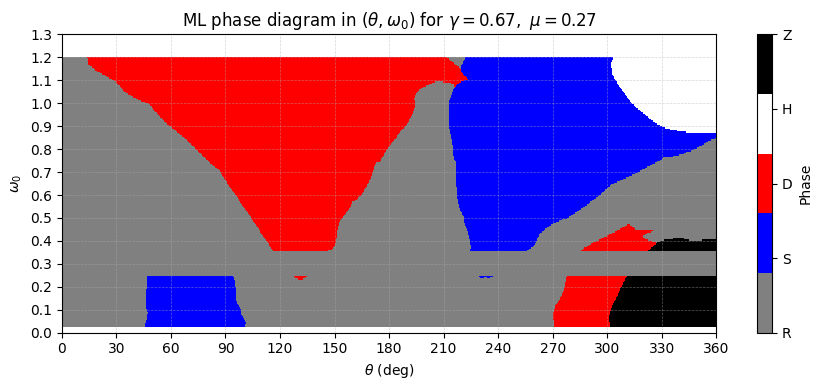

In [ ]:
ml_phase_diagram_theta_omega0(
    gamma=2.0/3.0,
    mu=0.27,
    mlp=model,
    scaler=scaler,
    mu_min_func=min_mu_for_pure_rolling,
    device=device,
)


In [16]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Assumptions: X, y already exist as numpy arrays ----
# X.shape == (685900, 4)
# y.shape == (685900,)

T = 100  # number of theta samples per trajectory
N, F = X.shape
assert F == 4, "Expected 4 features: (gamma, mu, omega0, theta)"

num_traj = N // T
assert num_traj * T == N, "N must be a multiple of T=100"

# Reshape into (num_traj, T, 4) and (num_traj, T)
X_seq = X.reshape(num_traj, T, F)
y_seq = y.reshape(num_traj, T)

print("X_seq shape:", X_seq.shape)  # (6859, 100, 4)
print("y_seq shape:", y_seq.shape)  # (6859, 100)


X_seq shape: (6859, 100, 4)
y_seq shape: (6859, 100)


In [17]:
from sklearn.model_selection import train_test_split

traj_indices = np.arange(num_traj)

train_idx, temp_idx = train_test_split(
    traj_indices, test_size=0.3, random_state=0, shuffle=True
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=0, shuffle=True
)
print(len(train_idx), len(val_idx), len(test_idx))

X_train = X_seq[train_idx]
y_train = y_seq[train_idx]

X_val   = X_seq[val_idx]
y_val   = y_seq[val_idx]

X_test  = X_seq[test_idx]
y_test  = y_seq[test_idx]


4801 1029 1029


In [48]:
class HoopSequenceDataset(Dataset):
    def __init__(self, X_seq, y_seq):
        # X_seq: (num_traj, T, 4), y_seq: (num_traj, T)
        self.X = torch.from_numpy(X_seq).float()
        self.y = torch.from_numpy(y_seq).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = HoopSequenceDataset(X_train, y_train)
val_ds   = HoopSequenceDataset(X_val,   y_val)
test_ds  = HoopSequenceDataset(X_test,  y_test)

batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


In [49]:
class HoopGRU(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=1, num_classes=5):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        x: (batch, T, 4)
        returns logits: (batch, T, num_classes)
        """
        h_seq, _ = self.gru(x)          # (batch, T, hidden_dim)
        logits = self.out(h_seq)        # (batch, T, num_classes)
        return logits


model = HoopGRU(input_dim=4, hidden_dim=64, num_layers=1, num_classes=5).to(device)


In [50]:
# Flatten y_train and compute class frequencies
y_train_flat = y_train.reshape(-1)
num_classes = 5
counts = np.bincount(y_train_flat, minlength=num_classes)
print("Class counts:", counts)

# Inverse-frequency weights
class_weights = counts.sum() / (counts + 1e-8)
class_weights = class_weights / class_weights.mean()  # normalize a bit
print("Class weights:", class_weights)

class_weights_t = torch.from_numpy(class_weights).float().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)


Class counts: [186482 155214 126140   4686   7578]
Class weights: [0.07343899 0.08823334 0.10857024 2.92254581 1.80721162]


In [51]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def sequence_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)      # (batch, T, 4)
            yb = yb.to(device)      # (batch, T)
            logits = model(Xb)      # (batch, T, 5)
            preds = logits.argmax(dim=-1)  # (batch, T)
            correct += (preds == yb).sum().item()
            total   += yb.numel()
    return correct / total


Epoch 01 | train loss = 1.2737 | val loss = 1.1196 | val acc = 0.4153
Epoch 02 | train loss = 0.9620 | val loss = 0.9074 | val acc = 0.4566
Epoch 03 | train loss = 0.8644 | val loss = 0.8082 | val acc = 0.5015
Epoch 04 | train loss = 0.7670 | val loss = 0.6942 | val acc = 0.5880
Epoch 05 | train loss = 0.6843 | val loss = 0.6544 | val acc = 0.5926
Epoch 06 | train loss = 0.6253 | val loss = 0.6027 | val acc = 0.6206
Epoch 07 | train loss = 0.5821 | val loss = 0.6671 | val acc = 0.6180
Epoch 08 | train loss = 0.5722 | val loss = 0.5324 | val acc = 0.6671
Epoch 09 | train loss = 0.5578 | val loss = 0.5660 | val acc = 0.6531
Epoch 10 | train loss = 0.5409 | val loss = 0.5715 | val acc = 0.6276
Epoch 11 | train loss = 0.5152 | val loss = 0.5905 | val acc = 0.7161
Epoch 12 | train loss = 0.5370 | val loss = 0.5038 | val acc = 0.6819
Epoch 13 | train loss = 0.5143 | val loss = 0.4976 | val acc = 0.6814
Epoch 14 | train loss = 0.4830 | val loss = 0.4803 | val acc = 0.7142
Epoch 15 | train los

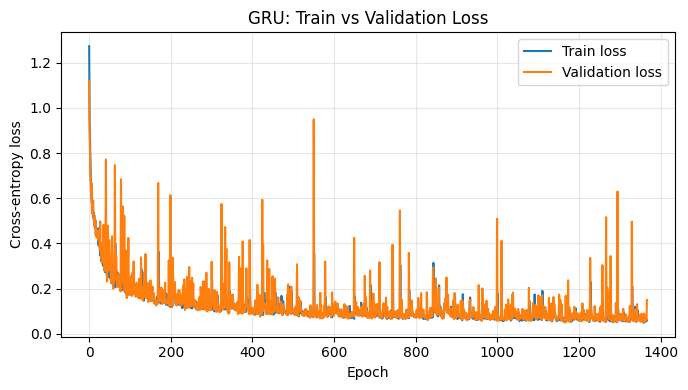

In [52]:
import matplotlib.pyplot as plt

num_epochs = 2000          # max epochs; early stopping will cut this short
patience   = 200           # stop if val loss doesn't improve for 200 epochs

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

train_losses = []
val_losses   = []
val_accs     = []

for epoch in range(1, num_epochs + 1):
    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    total_tokens = 0

    for Xb, yb in train_loader:
        Xb = Xb.to(device)    # (batch, T, 4)
        yb = yb.to(device)    # (batch, T)

        optimizer.zero_grad()
        logits = model(Xb)    # (batch, T, 5)

        B, T_, C = logits.shape
        loss = criterion(
            logits.view(B * T_, C),
            yb.view(B * T_)
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * B * T_
        total_tokens += B * T_

    train_loss = running_loss / total_tokens
    train_losses.append(train_loss)

    # ---------- VALIDATION LOSS ----------
    model.eval()
    val_running_loss = 0.0
    val_total_tokens = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            logits = model(Xb)

            B, T_, C = logits.shape
            val_loss_batch = criterion(
                logits.view(B * T_, C),
                yb.view(B * T_)
            )

            val_running_loss += val_loss_batch.item() * B * T_
            val_total_tokens += B * T_

    val_loss = val_running_loss / val_total_tokens
    val_losses.append(val_loss)

    # also track validation accuracy (for logging)
    val_acc = sequence_accuracy(val_loader)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | train loss = {train_loss:.4f} | "
          f"val loss = {val_loss:.4f} | val acc = {val_acc:.4f}")

    # ---------- EARLY STOPPING ----------
    if val_loss < best_val_loss - 1e-6:   # small tolerance
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # save best model so far
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

# restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ---------- FINAL TEST ACCURACY ----------
test_acc = sequence_accuracy(test_loader)
print("\nFinal test accuracy (per-step):", test_acc)

# ---------- PLOT TRAIN vs VAL LOSS ----------
plt.figure(figsize=(7,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("GRU: Train vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def collect_preds(loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb)
            preds = logits.argmax(dim=-1)

            all_preds.append(preds.cpu().numpy().reshape(-1))
            all_labels.append(yb.cpu().numpy().reshape(-1))

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_preds, all_labels


preds, labels = collect_preds(test_loader)

print("Test accuracy:", (preds == labels).mean())

target_names = ["R", "S", "D", "H", "Z"]
print(classification_report(labels, preds, target_names=target_names))

print("Confusion matrix:")
print(confusion_matrix(labels, preds))


Test accuracy: 0.9373760932944606
              precision    recall  f1-score   support

           R       0.98      0.89      0.93     37902
           S       0.93      0.97      0.95     34331
           D       0.94      0.96      0.95     27811
           H       0.51      1.00      0.68      1039
           Z       0.73      1.00      0.84      1817

    accuracy                           0.94    102900
   macro avg       0.82      0.96      0.87    102900
weighted avg       0.94      0.94      0.94    102900

Confusion matrix:
[[33691  2126  1583   276   226]
 [  386 33143    87   710     5]
 [  300   293 26768     0   450]
 [    0     0     0  1039     0]
 [    2     0     0     0  1815]]


In [63]:
# Get the integer labels for 'H' and 'Z'
H_label = PHASE_TO_INT['H']
Z_label = PHASE_TO_INT['Z']

# --- Confusion Matrix for 'H' (Hop) vs. 'not H' ---
# Create binary true labels: 1 if H, 0 otherwise
h_true_binary = (labels == H_label).astype(int)
# Create binary predicted labels: 1 if H, 0 otherwise
h_pred_binary = (preds == H_label).astype(int)

confusion_matrix_h = confusion_matrix(h_true_binary, h_pred_binary)

print("\n2x2 Confusion Matrix for 'H' (Hop) vs. 'not H':")
print("True H | Predicted H | Predicted not H")
print("------------------------------------")
print(f"True H    | {confusion_matrix_h[1, 1]:<11} | {confusion_matrix_h[1, 0]:<15}") # Note: sklearn's CM is TN FP / FN TP
print(f"True not H| {confusion_matrix_h[0, 1]:<11} | {confusion_matrix_h[0, 0]:<15}")
# For clarity, let's print the standard sklearn output as well
# print(confusion_matrix_h)

# --- Confusion Matrix for 'Z' (Zero) vs. 'not Z' ---
# Create binary true labels: 1 if Z, 0 otherwise
z_true_binary = (labels == Z_label).astype(int)
# Create binary predicted labels: 1 if Z, 0 otherwise
z_pred_binary = (preds == Z_label).astype(int)

confusion_matrix_z = confusion_matrix(z_true_binary, z_pred_binary)

print("\n2x2 Confusion Matrix for 'Z' (Zero) vs. 'not Z':")
print("True Z | Predicted Z | Predicted not Z")
print("------------------------------------")
print(f"True Z    | {confusion_matrix_z[1, 1]:<11} | {confusion_matrix_z[1, 0]:<15}")
print(f"True not Z| {confusion_matrix_z[0, 1]:<11} | {confusion_matrix_z[0, 0]:<15}")
# print(confusion_matrix_z)



2x2 Confusion Matrix for 'H' (Hop) vs. 'not H':
True H | Predicted H | Predicted not H
------------------------------------
True H    | 1039        | 0              
True not H| 986         | 100875         

2x2 Confusion Matrix for 'Z' (Zero) vs. 'not Z':
True Z | Predicted Z | Predicted not Z
------------------------------------
True Z    | 1815        | 2              
True not Z| 681         | 100402         


In [54]:
import torch
import numpy as np

def build_sequence(gamma, mu, omega0, num_steps=100):
    """
    Build the (γ, μ, ω0, θ) sequence for a full revolution.
    θ goes from 0 to 2π (or 0 to 360° if degrees preferred).
    """
    theta_vals = np.linspace(0, 2*np.pi, num_steps)  # radians
    X = np.column_stack([
        np.full(num_steps, gamma),
        np.full(num_steps, mu),
        np.full(num_steps, omega0),
        theta_vals
    ])
    return X.astype(np.float32)


In [55]:
def gru_predict_sequence(model, X_seq):
    """
    Run the GRU on a full sequence X_seq of shape (T,4).
    Returns predicted labels (length T).
    """
    model.eval()

    device = next(model.parameters()).device   # ← automatically detects cuda/cpu

    inp = torch.tensor(X_seq, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        logits = model(inp)              # shape: (1, T, num_classes)
        preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()

    return preds


In [56]:
def is_pure_rolling(omega0, gamma=2/3, mu=0.27):
    return mu > min_mu_for_pure_rolling(gamma, omega0)

In [57]:
def gru_phase_diagram_sequence(
    model, min_mu_for_pure_rolling,
    gamma=2/3, mu=0.27,
    num_omega=200, num_theta=100
):
    """
    GRU-based phase diagram using true sequence predictions,
    with plotting that matches the simulation phase diagram style.
    """

    # ---- θ grid in degrees (consistent with simulator) ----
    theta_vals_deg = np.linspace(0, 360, num_theta)

    # ---- ω0 sampling ----
    omega0_max = 1.0 / math.sqrt(gamma)
    omega0_min = 0.02 * omega0_max
    omega0_hi  = 0.98 * omega0_max

    omega_vals = np.linspace(omega0_min, omega0_hi, num_omega)

    # ---- Output image ----
    Z = np.zeros((num_omega, num_theta), dtype=int)

    # ---- Loop over ω0 ----
    for i, omega0 in enumerate(omega_vals):

        # Pure rolling band
        if mu > min_mu_for_pure_rolling(gamma, omega0):
            Z[i, :] = 0  # R (class 0)
            continue

        # Build input sequence
        X_seq = build_sequence(gamma, mu, omega0, num_steps=num_theta)

        # Predict sequence via GRU
        preds = gru_predict_sequence(model, X_seq)

        Z[i, :] = preds

    # ------------------------------------------------------------------
    # PLOTTING — MATCHING SIMULATION DIAGRAM
    # ------------------------------------------------------------------

    # Phase colors (same as simulation)
    phase_colors = [
        PHASE_COLORS["R"],   # 0
        PHASE_COLORS["S"],   # 1
        PHASE_COLORS["D"],   # 2
        PHASE_COLORS["H"],   # 3
        PHASE_COLORS["Z"],   # 4
    ]
    cmap = ListedColormap(phase_colors)

    extent = [0, 360, omega0_min, omega0_hi]

    plt.figure(figsize=(9, 4))
    plt.imshow(
        Z,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
        extent=extent
    )

    # Colorbar
    cb = plt.colorbar(ticks=[0, 1, 2, 3, 4])
    cb.ax.set_yticklabels(["R", "S", "D", "H", "Z"])
    cb.set_label("Phase")

    # Axes & labels
    plt.xlabel(r"$\theta$ (deg)")
    plt.ylabel(r"$\omega_0$")
    plt.title(fr"GRU-based phase diagram for $\gamma={gamma:.3f},\ \mu={mu:.3f}$")

    # ---- Theron-style ticks & grid ----
    ax = plt.gca()
    ax.set_xlim(0, 360)

    # Round ω0 upper limit to nearest 0.1
    y_max = math.ceil(omega0_hi * 10) / 10
    ax.set_ylim(omega0_min, y_max)

    ax.xaxis.set_major_locator(MultipleLocator(30))   # 30° steps
    ax.yaxis.set_major_locator(MultipleLocator(0.1))  # 0.1 steps

    ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()

    return Z


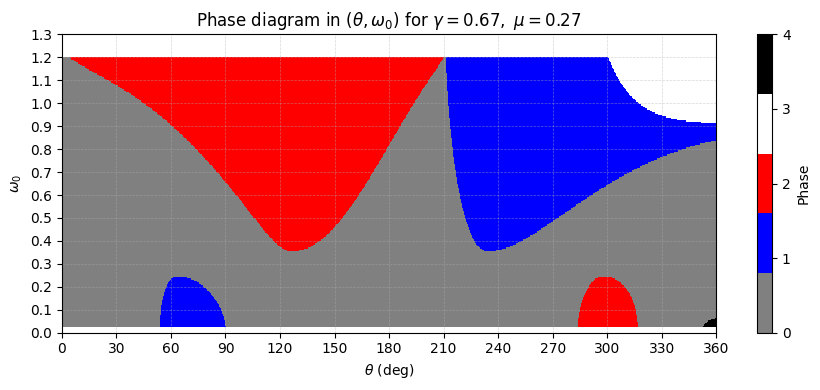

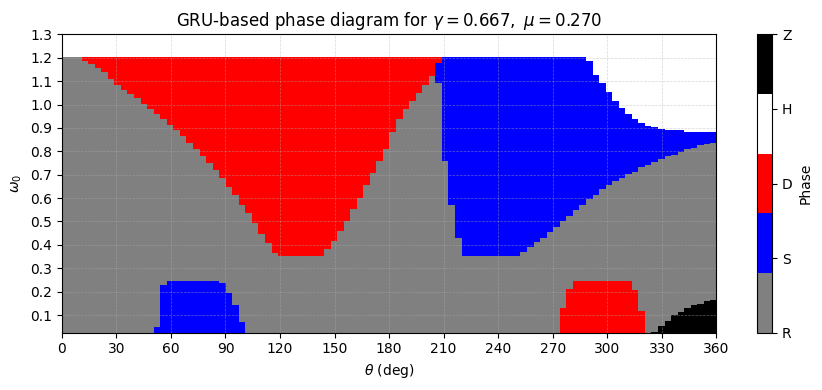

array([[0, 0, 0, ..., 4, 4, 4],
       [0, 0, 0, ..., 4, 4, 4],
       [0, 0, 0, ..., 4, 4, 4],
       ...,
       [0, 0, 0, ..., 3, 3, 3],
       [0, 0, 0, ..., 3, 3, 3],
       [0, 0, 0, ..., 3, 3, 3]])

In [61]:
phase_diagram_theta_omega0(gamma=2/3, mu=0.27)
gru_phase_diagram_sequence(model, min_mu_for_pure_rolling, gamma=2/3, mu=0.27)